<a href="https://colab.research.google.com/github/ArnouldNicolas/intro-traitement-donn-es/blob/main/classification_regressionLin%C3%A9aire_par_morceaux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import seaborn as sns

from sklearn import set_config

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [60]:
df=pd.read_csv('/content/sample_data/insurance.csv')


Dataset chargé : 1338 lignes
smoker
no     1064
yes     274
Name: count, dtype: int64
count    1338.000000
mean        9.098659
std         0.919527
min         7.022756
25%         8.463853
50%         9.146552
75%         9.719558
max        11.063045
Name: charges, dtype: float64


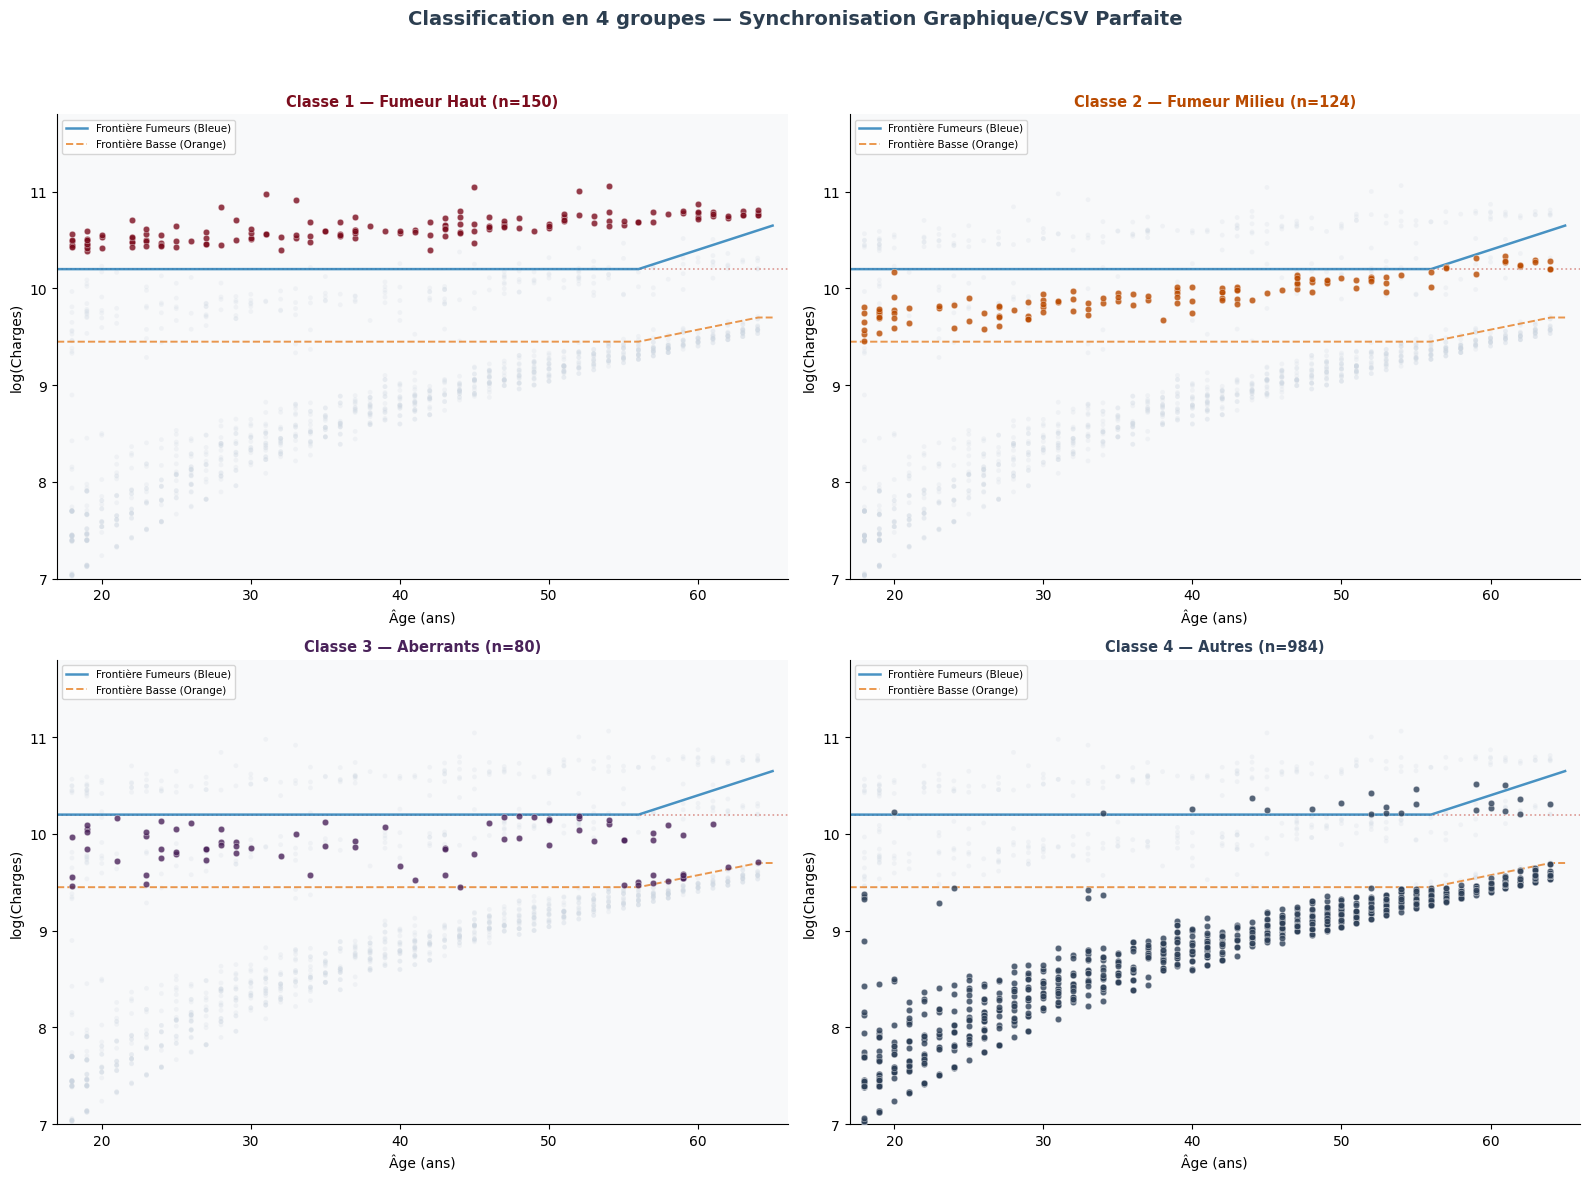

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Chargement du dataset ─────────────────────────────────────
df = pd.read_csv('/content/sample_data/insurance.csv')

if df['charges'].max() > 100:
    df['charges'] = np.log(df['charges'])

print(f"Dataset chargé : {df.shape[0]} lignes")
print(df['smoker'].value_counts())
print(df['charges'].describe())

# ── Paramètres ───────────────────────────────────────────────
B_HIGH     = 10.2
B_HIGH_END = 10.6
AGE_PIVOT  = 56
TARGET     = 79


best_params = None
best_diff   = float('inf')
n_div       = 64 - AGE_PIVOT

for t_y in np.arange(9.0, 10.1, 0.05):
    for t_o in np.arange(t_y + 0.05, 10.5, 0.05):
        lth = np.where(
            df['age'] < AGE_PIVOT,
            t_y,
            np.minimum(t_o, t_y + (t_o - t_y) * (df['age'] - AGE_PIVOT) / n_div)
        )
        n    = int(((df['smoker'] == 'no') &
                    (df['charges'] >= lth) &
                    (df['charges'] <= B_HIGH)).sum())
        diff = abs(n - TARGET)
        if diff < best_diff:
            best_diff   = diff
            best_params = (t_y, t_o, n)

T_YOUNG, T_OLD, n_found = best_params

# ── INTÉGRATION DES FRONTIÈRES DANS LE DATAFRAME ─────────────
df['lower_th'] = np.where(
    df['age'] < AGE_PIVOT,
    T_YOUNG,
    np.minimum(T_OLD, T_YOUNG + (T_OLD - T_YOUNG) * (df['age'] - AGE_PIVOT) / n_div)
)

df['upper_th_smokers'] = np.where(
    df['age'] < AGE_PIVOT,
    B_HIGH,
    B_HIGH + (B_HIGH_END - B_HIGH) * (df['age'] - AGE_PIVOT) / n_div
)

# ── CLASSIFICATION ────────────────────────────────────────────
sm = df['smoker'] == 'yes'
nf = df['smoker'] == 'no'

classe1 = df[sm & (df['charges'] >= df['upper_th_smokers'])].copy()
classe2 = df[sm & (df['charges'] <  df['upper_th_smokers'])].copy()

mask_abt = nf & (df['charges'] >= df['lower_th']) & (df['charges'] <= B_HIGH)
classe3  = df[mask_abt].copy()

mask_autres = ~(df.index.isin(classe1.index) |
                df.index.isin(classe2.index) |
                df.index.isin(classe3.index))
classe4 = df[mask_autres].copy()

assert len(classe1)+len(classe2)+len(classe3)+len(classe4) == len(df), \
    "Erreur : perte de données lors de la séparation"

# ── Palettes ─────────────────────────────────────────────────
COUL = {
    'c1': '#7B0D1E',
    'c2': '#B94A00',
    'c3': '#4A235A',
    'c4': '#2E4057',
}
GRAY = '#CBD5E0'

# ── Lignes pour le plot ───────────────────────────────────────
ages_line = np.linspace(17, 65, 300)
thresh_line_low = np.where(
    ages_line < AGE_PIVOT,
    T_YOUNG,
    np.minimum(T_OLD, T_YOUNG + (T_OLD - T_YOUNG) * (ages_line - AGE_PIVOT) / n_div)
)
thresh_line_high_smokers = np.where(
    ages_line < AGE_PIVOT,
    B_HIGH,
    B_HIGH + (B_HIGH_END - B_HIGH) * (ages_line - AGE_PIVOT) / n_div
)

# ── FIGURE ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FFFFFF')


fig.suptitle(
    "Classification en 4 groupes — Synchronisation Graphique/CSV Parfaite",
    fontsize=14, fontweight='bold', color='#2C3E50'
)

configs = [
    (axes[0,0], classe1, 'c1', f'Classe 1 — Fumeur Haut (n={len(classe1)})'),
    (axes[0,1], classe2, 'c2', f'Classe 2 — Fumeur Milieu (n={len(classe2)})'),
    (axes[1,0], classe3, 'c3', f'Classe 3 — Aberrants (n={len(classe3)})'),
    (axes[1,1], classe4, 'c4', f'Classe 4 — Autres (n={len(classe4)})'),
]

for ax, data, cle, titre in configs:
    ax.set_facecolor('#F8F9FA')

    autres = df[~df.index.isin(data.index)]
    ax.scatter(autres['age'], autres['charges'],
               c=GRAY, s=12, alpha=0.20, edgecolors='none', zorder=1)

    ax.scatter(data['age'], data['charges'],
               c=COUL[cle], s=22, alpha=0.80, edgecolors='white', linewidth=0.3, zorder=3)

    ax.hlines(B_HIGH, 17, 66, color='#C0392B', lw=1.2, ls=':', alpha=0.5)
    ax.plot(ages_line, thresh_line_high_smokers, color='#2980B9', lw=1.8, ls='-',
            alpha=0.85, label='Frontière Fumeurs (Bleue)')
    ax.plot(ages_line, thresh_line_low, color='#E67E22', lw=1.4, ls='--',
            alpha=0.8, label='Frontière Basse (Orange)')

    ax.set_xlabel('Âge (ans)', fontsize=10)
    ax.set_ylabel('log(Charges)', fontsize=10)
    ax.set_xlim(17, 66)
    ax.set_ylim(7.0, 11.8)
    ax.set_title(titre, fontsize=10.5, fontweight='bold', color=COUL[cle])
    ax.legend(fontsize=7.5, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#  FIX affichage : rect réserve l'espace pour le suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('classification_synchro_csv.png', dpi=150, bbox_inches='tight',
            facecolor='white', pad_inches=0.3)
plt.show()




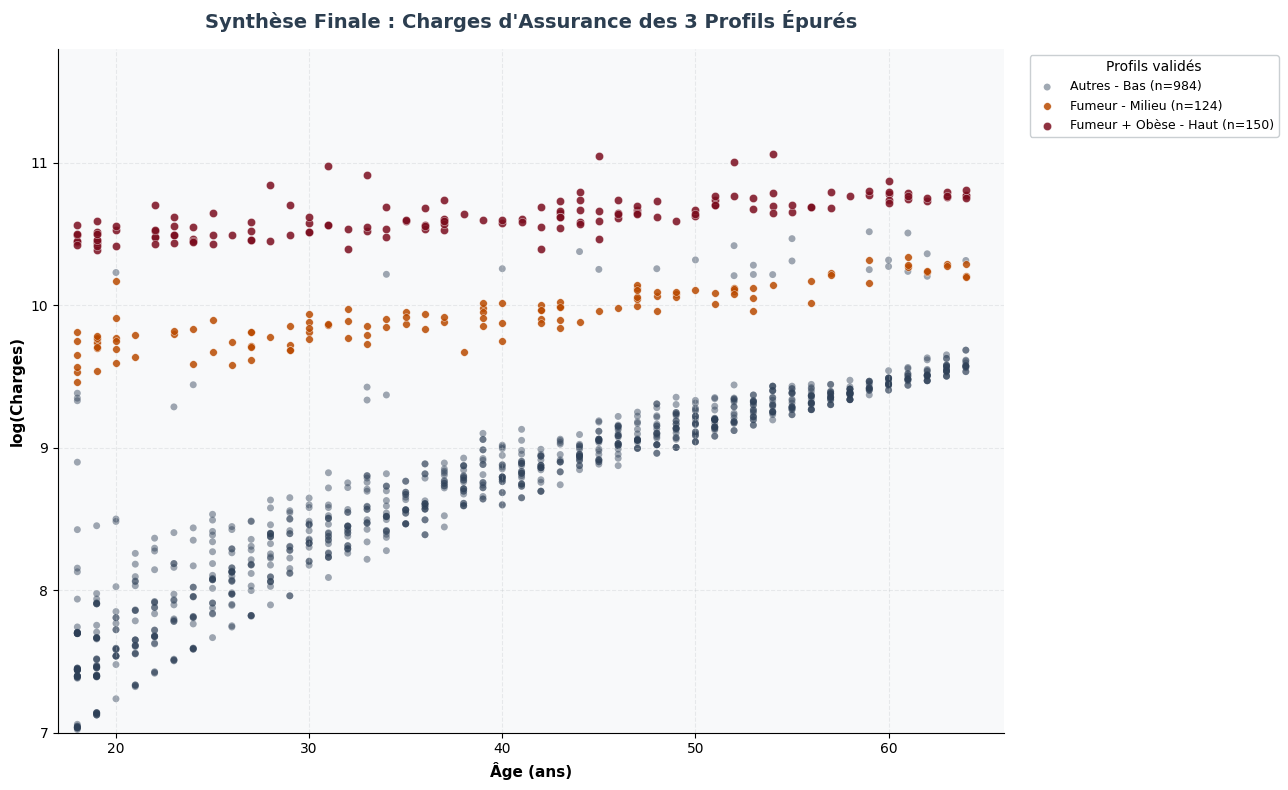

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des 3 datasets demandés (on exclut df2 comme tu l'as souhaité)
df1 = pd.read_csv('/content/classe4_autres_bas1.csv')       # Autres bas
df3 = pd.read_csv('/content/classe2_fumeurs_milieu1.csv')   # Fumeur simple
df4 = pd.read_csv('/content/classe1_fumeurs_haut1.csv')     # Fumeur + Obèse

# 2. Configuration de la figure unique
plt.figure(figsize=(13, 8))
ax = plt.gca()
ax.set_facecolor('#F8F9FA') # Fond clair moderne
plt.grid(True, linestyle='--', alpha=0.3, color='#BDC3C7', zorder=0)

# 3. Tracé des 3 groupes avec tes couleurs spécifiques
# On applique une légère transparence (alpha) sur la classe 4 car elle contient beaucoup de points
plt.scatter(
    df1['age'], df1['charges'],
    c='#2E4057', s=25, alpha=0.45, edgecolors='none',
    label=f'Autres - Bas (n={len(df1)})', zorder=1
)

plt.scatter(
    df3['age'], df3['charges'],
    c='#B94A00', s=30, alpha=0.85, edgecolors='white', linewidths=0.3,
    label=f'Fumeur - Milieu (n={len(df3)})', zorder=2
)

plt.scatter(
    df4['age'], df4['charges'],
    c='#7B0D1E', s=35, alpha=0.85, edgecolors='white', linewidths=0.3,
    label=f'Fumeur + Obèse - Haut (n={len(df4)})', zorder=3
)

# 4. Personnalisation des axes et du titre
plt.title("Synthèse Finale : Charges d'Assurance des 3 Profils Épurés", fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Âge (ans)', fontsize=11, fontweight='bold')
plt.ylabel('log(Charges)', fontsize=11, fontweight='bold')

# Maintien des échelles d'origine pour une cohérence parfaite avec tes analyses
plt.xlim(17, 66)
plt.ylim(7.0, 11.8)

# Légende élégante déportée sur le côté
plt.legend(
    title='Profils validés',
    title_fontsize=10,
    fontsize=9,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    edgecolor='#BDC3C7'
)

# Nettoyage cosmétique des bordures
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

 Précision du modèle (R2 Score) : 0.9228

 Poids de chaque variable :
            Variable  Coefficient
2          children     0.137500
0               age     0.045400
1               bmi     0.000076
4  region_northwest    -0.050198
3          sex_male    -0.094714
5  region_southeast    -0.136833
6  region_southwest    -0.150288

 RÉSULTAT DE LA PRÉDICTION :
Valeur logarithmique prévue : 9.18
Facture finale estimée : 9662.59 $


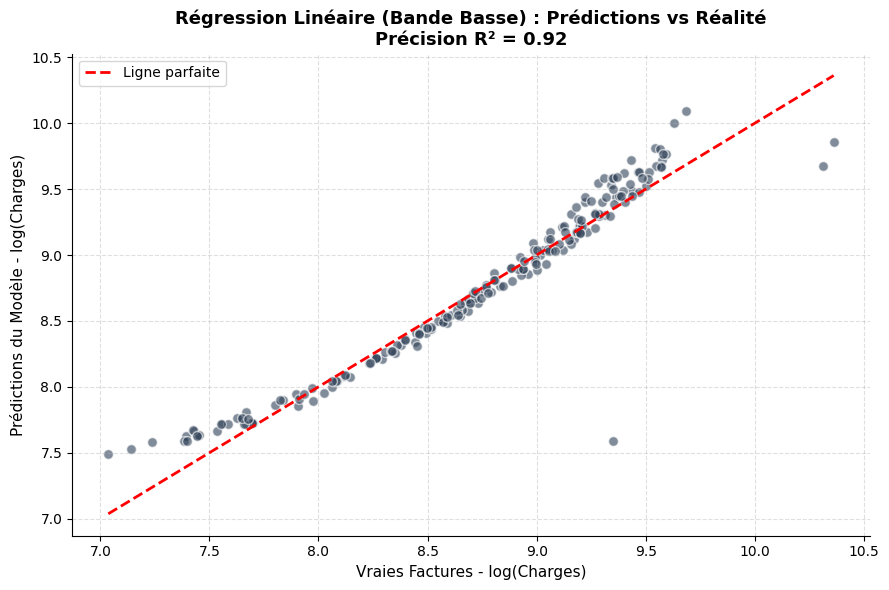

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Charger ton dataset de la Classe 4 (Bande Basse)
df = pd.read_csv('classe4_autres_bas1.csv')

# 2. Préparation des données
# On ignore 'smoker' car ce groupe ne contient que des 'no'
X = df[['age', 'sex', 'bmi', 'children', 'region']].copy()

# Encodage (One-Hot) pour transformer les textes (sex, region) en nombres (0 ou 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# La cible est la colonne 'charges' (qui est déjà en log d'après notre nettoyage précédent)
y = df['charges']

# 3. Séparation Train / Test (80% pour apprendre, 20% pour tester)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Modélisation
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Évaluation
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f" Précision du modèle (R2 Score) : {r2:.4f}\n")

# Affichage des coefficients pour comprendre ce qui pèse sur les charges
coefs = pd.DataFrame({'Variable': X_encoded.columns, 'Coefficient': model.coef_})
print(" Poids de chaque variable :\n", coefs.sort_values(by='Coefficient', ascending=False))

# ============================================================
# 6. COMMENT FAIRE UNE PRÉDICTION SUR UN NOUVEAU PATIENT
# ============================================================
# Créons un nouveau patient fictif
nouveau_patient = pd.DataFrame({
    'age': [45],
    'sex': ['female'],
    'bmi': [32.0],        # Patient obèse
    'children': [2],
    'region': ['northwest']
})

# Il faut encoder le nouveau patient exactement de la même manière que X
patient_encode = pd.get_dummies(nouveau_patient)
patient_encode = patient_encode.reindex(columns=X_encoded.columns, fill_value=0)

# Faire la prédiction (qui nous donne le résultat en logarithme)
prediction_log = model.predict(patient_encode)[0]

# Convertir le log en vrai montant en dollars grâce à l'exponentielle (np.exp)
prediction_dollars = np.exp(prediction_log)

print(f"\n RÉSULTAT DE LA PRÉDICTION :")
print(f"Valeur logarithmique prévue : {prediction_log:.2f}")
print(f"Facture finale estimée : {prediction_dollars:.2f} $")

# ============================================================
# 7. TRACER LE GRAPHIQUE DES PRÉDICTIONS VS RÉALITÉ
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2E4057', edgecolor='white', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ligne parfaite")
plt.title(f"Régression Linéaire (Bande Basse) : Prédictions vs Réalité\nPrécision R² = {r2:.2f}", fontsize=13, fontweight='bold')
plt.xlabel("Vraies Factures - log(Charges)", fontsize=11)
plt.ylabel("Prédictions du Modèle - log(Charges)", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

 Précision du modèle (R2 Score) : 0.9840

Poids de chaque variable :
            Variable  Coefficient
1               bmi     0.023248
2          children     0.019730
0               age     0.011643
4  region_northwest     0.009942
5  region_southeast     0.007412
6  region_southwest     0.005097
3          sex_male    -0.039953

 RÉSULTAT DE LA PRÉDICTION :
Valeur logarithmique prévue : 9.89
Facture finale estimée : 19727.10 $


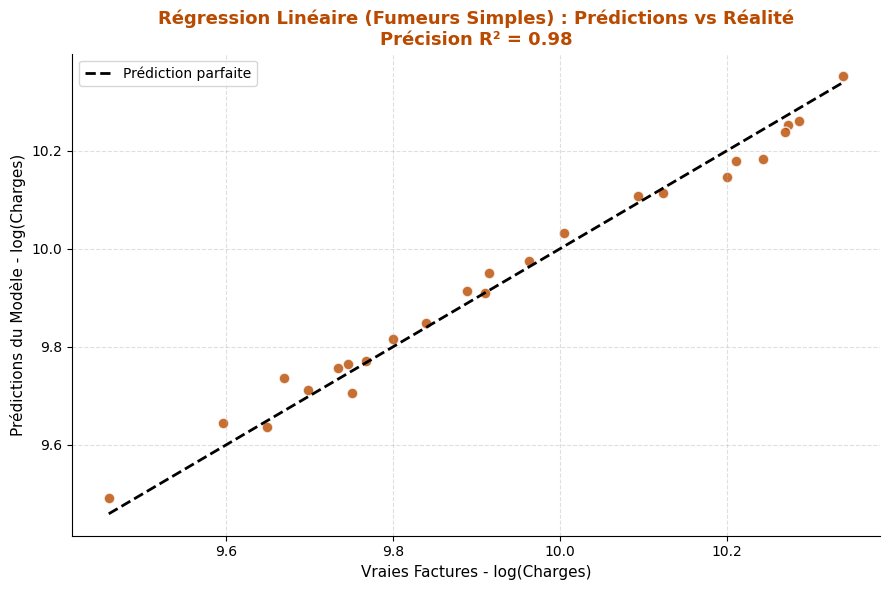

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Charger le dataset des Fumeurs Simples (Classe 2)
df = pd.read_csv('classe2_fumeurs_milieu1.csv')

# 2. Préparation des données (on ignore la colonne 'smoker' car ce ne sont que des "yes")
X = df[['age', 'sex', 'bmi', 'children', 'region']].copy()

# Encodage pour les catégories textuelles
X_encoded = pd.get_dummies(X, drop_first=True)
y = df['charges']

# 3. Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Évaluation et métriques
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f" Précision du modèle (R2 Score) : {r2:.4f}\n")

# Affichage du poids des variables
coefs = pd.DataFrame({'Variable': X_encoded.columns, 'Coefficient': model.coef_})
print("Poids de chaque variable :\n", coefs.sort_values(by='Coefficient', ascending=False))

# ============================================================
# 6. PRÉDICTION SUR UN NOUVEAU PATIENT
# ============================================================
nouveau_patient = pd.DataFrame({
    'age': [35],
    'sex': ['male'],
    'bmi': [26.5],       # Attention: Pour coller à cette classe, l'IMC doit être < 30
    'children': [1],
    'region': ['southwest']
})

patient_encode = pd.get_dummies(nouveau_patient)
patient_encode = patient_encode.reindex(columns=X_encoded.columns, fill_value=0)

prediction_log = model.predict(patient_encode)[0]
prediction_dollars = np.exp(prediction_log)

print(f"\n RÉSULTAT DE LA PRÉDICTION :")
print(f"Valeur logarithmique prévue : {prediction_log:.2f}")
print(f"Facture finale estimée : {prediction_dollars:.2f} $")

# ============================================================
# 7. TRACER LE GRAPHIQUE PRÉDICTIONS VS RÉALITÉ
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.8, color='#B94A00', edgecolor='white', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Prédiction parfaite")
plt.title(f"Régression Linéaire (Fumeurs Simples) : Prédictions vs Réalité\nPrécision R² = {r2:.2f}", fontsize=13, fontweight='bold', color='#B94A00')
plt.xlabel("Vraies Factures - log(Charges)", fontsize=11)
plt.ylabel("Prédictions du Modèle - log(Charges)", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

 Précision du modèle (R2 Score) : 0.9014

 Poids de chaque variable :
            Variable  Coefficient
4  region_northwest     0.016118
1               bmi     0.013070
0               age     0.006731
2          children     0.001270
6  region_southwest    -0.006401
5  region_southeast    -0.012672
3          sex_male    -0.014066

 RÉSULTAT DE LA PRÉDICTION :
Valeur logarithmique prévue : 10.64
Facture finale estimée : 41583.07 $


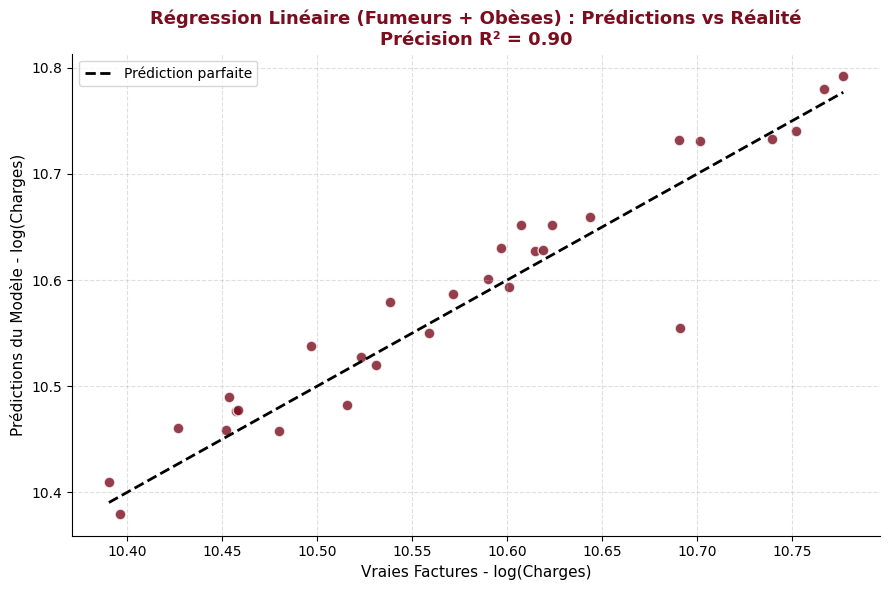

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Charger le dataset des Fumeurs Obèses (Classe 1)
df = pd.read_csv('classe1_fumeurs_haut1.csv')

# 2. Préparation des données (on ignore 'smoker' car ce ne sont que des "yes")
X = df[['age', 'sex', 'bmi', 'children', 'region']].copy()

# Encodage des variables textuelles
X_encoded = pd.get_dummies(X, drop_first=True)
y = df['charges']

# 3. Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Entraînement du modèle de régression
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Évaluation des performances
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f" Précision du modèle (R2 Score) : {r2:.4f}\n")

# Affichage des coefficients
coefs = pd.DataFrame({'Variable': X_encoded.columns, 'Coefficient': model.coef_})
print(" Poids de chaque variable :\n", coefs.sort_values(by='Coefficient', ascending=False))

# ============================================================
# 6. PRÉDICTION SUR UN NOUVEAU PATIENT
# ============================================================
nouveau_patient = pd.DataFrame({
    'age': [40],
    'sex': ['female'],
    'bmi': [35.5],       # IMC >= 30 obligatoire pour coller à ce groupe
    'children': [1],
    'region': ['southeast']
})

patient_encode = pd.get_dummies(nouveau_patient)
patient_encode = patient_encode.reindex(columns=X_encoded.columns, fill_value=0)

prediction_log = model.predict(patient_encode)[0]
prediction_dollars = np.exp(prediction_log)

print(f"\n RÉSULTAT DE LA PRÉDICTION :")
print(f"Valeur logarithmique prévue : {prediction_log:.2f}")
print(f"Facture finale estimée : {prediction_dollars:.2f} $")

# ============================================================
# 7. TRACER LE GRAPHIQUE PRÉDICTIONS VS RÉALITÉ00
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.8, color='#7B0D1E', edgecolor='white', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Prédiction parfaite")
plt.title(f"Régression Linéaire (Fumeurs + Obèses) : Prédictions vs Réalité\nPrécision R² = {r2:.2f}", fontsize=13, fontweight='bold', color='#7B0D1E')
plt.xlabel("Vraies Factures - log(Charges)", fontsize=11)
plt.ylabel("Prédictions du Modèle - log(Charges)", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ============================================================
# 1. CONFIGURATION DES FICHIERS ET DES CAS D'ÉTUDE
# ============================================================
# On définit l'emplacement exact de tes fichiers et leurs étiquettes
liste_cas = [
    {
        "nom": "Classe 1 — Fumeurs + Obèses (Bande Haute)",
        "chemin": "/content/classe1_fumeurs_haut1.csv",
        "couleur_print": "\033[91m" # Rouge pour l'affichage console
    },
    {
        "nom": "Classe 2 — Fumeurs Simples (Bande Milieu)",
        "chemin": "/content/classe2_fumeurs_milieu1.csv",
        "couleur_print": "\033[93m" # Orange/Jaune pour l'affichage console
    },
    {
        "nom": "Classe 4 — Autres / Non-fumeurs (Bande Basse)",
        "chemin": "/content/classe4_autres_bas1.csv",
        "couleur_print": "\033[92m" # Vert pour l'affichage console
    }
]

# Fin de couleur pour la console
RESET = "\033[0m"

# ============================================================
# 2. BOUCLE D'ENTRAÎNEMENT ET D'ANALYSE AUTOMATIQUE
# ============================================================
for cas in liste_cas:
    print(f"\n{cas['couleur_print']}" + "="*60)
    print(f" ANALYSE : {cas['nom']}")
    print("="*60 + f"{RESET}")

    # A. Chargement du fichier réel
    try:
        df = pd.read_csv(cas['chemin'])
    except FileNotFoundError:
        print(f" Impossible de trouver le fichier à l'adresse : {cas['chemin']}. Vérifie le nom ou l'importation.")
        continue

    # B. Isolation des variables explicatives (X) et de la cible (y)
    # On ignore 'smoker' car il est constant au sein de chaque fichier isolé
    X = df[['age', 'sex', 'bmi', 'children', 'region']].copy()
    y = df['charges']

    # C. Encodage One-Hot automatique (Sexe et Régions convertis en 0 et 1)
    X_encoded = pd.get_dummies(X, drop_first=True)

    # D. Séparation Train (80%) / Test (20%) pour valider le modèle
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

    # E. Entraînement de la Régression Linéaire
    model = LinearRegression()
    model.fit(X_train, y_train)

    # F. Calcul de la performance (R²)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    # G. AFFICHAGE DES RÉSULTATS MAJEURS
    print(f" Précision du modèle (R² Score) : {r2:.4f}")
    print(f" INTERCEPT (Valeur constante de base) : {model.intercept_:.6f}\n")

    # H. Structuration et tri des coefficients du modèle
    coefs = pd.DataFrame({
        'Variable': X_encoded.columns,
        'Coefficient (Poids)': model.coef_
    })
    # On trie du coefficient le plus fort au plus faible
    coefs_tries = coefs.sort_values(by='Coefficient (Poids)', ascending=False).reset_index(drop=True)

    print(" Tableau des Coefficients (Poids de chaque variable) :")
    print(coefs_tries.to_string(index=False))
    print("\n" + "─"*60)


 ANALYSE : Classe 1 — Fumeurs + Obèses (Bande Haute)
 Précision du modèle (R² Score) : 0.9014
 INTERCEPT (Valeur constante de base) : 9.913643

 Tableau des Coefficients (Poids de chaque variable) :
        Variable  Coefficient (Poids)
region_northwest             0.016118
             bmi             0.013070
             age             0.006731
        children             0.001270
region_southwest            -0.006401
region_southeast            -0.012672
        sex_male            -0.014066

────────────────────────────────────────────────────────────

 ANALYSE : Classe 2 — Fumeurs Simples (Bande Milieu)
 Précision du modèle (R² Score) : 0.9840
 INTERCEPT (Valeur constante de base) : 8.881291

 Tableau des Coefficients (Poids de chaque variable) :
        Variable  Coefficient (Poids)
             bmi             0.023248
        children             0.019730
             age             0.011643
region_northwest             0.009942
region_southeast             0.007412
region